In [2]:
import pandas as pd
import numpy as np

import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

from gnews import GNews

from transformers import AutoTokenizer,AutoModelForSequenceClassification,pipeline,DistilBertTokenizer

In [1]:
'''gn = GNews(language='en', country='US', max_results=5)

# Top news
top = gn.get_top_news()

# Search by keyword
results = gn.get_news('artificial intelligence')

# By topic
tech_news = gn.get_news_by_topic('TECHNOLOGY')

# By location
india_news = gn.get_news_by_location('India')

# Full article
article = gn.get_full_article(results[0]['url'])
print(article.text))'''

"gn = GNews(language='en', country='US', max_results=5)\n\n# Top news\ntop = gn.get_top_news()\n\n# Search by keyword\nresults = gn.get_news('artificial intelligence')\n\n# By topic\ntech_news = gn.get_news_by_topic('TECHNOLOGY')\n\n# By location\nindia_news = gn.get_news_by_location('India')\n\n# Full article\narticle = gn.get_full_article(results[0]['url'])\nprint(article.text))"

In [10]:
def acquire_news_keyword(topic:str,results:int):
    gn=GNews(language='en', max_results=results)
    return gn.get_news(topic)

def acquire_news_top(results:int):
    gn=GNews(language='en', max_results=results)
    return gn.get_top_news()

def acquire_news_topic(topic:str,results:int):
    gn=GNews(language='en', max_results=results)
    return gn.get_news(topic)

def filter_new_news(new_news:pd.DataFrame,old_news:pd.DataFrame):
    x=0
    for index,title in enumerate(new_news.iloc[:,0]):
        if title in old_news.iloc[:,0].values:
            new_news.drop(index=index,axis=1,inplace=True)
            x=x+1
        else:
            pass
    print('Total news dropped:',x)

def record_news(new_news:pd.DataFrame,header:bool = False):
    new_news.to_csv(r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews\msftn_news.csv",header=header,index=False,mode='a')

def acquire_sentiment(new_news:pd.DataFrame):
    model_ckpt = "ProsusAI/finbert"
    classifier = pipeline('text-classification', model=model_ckpt)

    _ = [classifier(text, return_all_scores=True) for text in new_news.iloc[:, 1]]
    new_news['label'] = [res[0]['label'] for res in _]
    new_news['confidence'] = [res[0]['score'] for res in _]
    print(_)
    _.clear()


In [ ]:
msftn_df=pd.DataFrame(acquire_news_keyword(topic='Microsoft',results=100))
topn_df=pd.DataFrame(acquire_news_top(results=100))
fin_df=pd.DataFrame(acquire_news_topic(topic='Finance',results=100))

In [ ]:
msftn_df.head()

In [ ]:
msftn_df.shape

In [ ]:
topn_df.head()

In [ ]:
fin_df.head()

In [5]:
path=r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews\msftn_news.csv"
news_df=pd.read_csv(path)

In [ ]:
news_df.head()

In [ ]:
news_df.shape

In [ ]:
ndf=pd.DataFrame(acquire_news_keyword(topic='Microsoft',results=100))

In [ ]:
ndf.head()

In [ ]:
ndf.shape

In [ ]:
filter_new_news(new_news=ndf,old_news=news_df)

In [ ]:
ndf.shape

In [ ]:
ndf.head()

In [ ]:
record_news(ndf,header=False)

In [ ]:
del news_df

In [13]:
news_df=pd.read_csv(path)

In [14]:
acquire_sentiment(news_df)

[[{'label': 'neutral', 'score': 0.8556678295135498}], [{'label': 'neutral', 'score': 0.6045264601707458}], [{'label': 'neutral', 'score': 0.619557797908783}], [{'label': 'negative', 'score': 0.7841262817382812}], [{'label': 'neutral', 'score': 0.9121840596199036}], [{'label': 'neutral', 'score': 0.9157736897468567}], [{'label': 'negative', 'score': 0.8768852353096008}], [{'label': 'neutral', 'score': 0.8470796942710876}], [{'label': 'negative', 'score': 0.6440311074256897}], [{'label': 'neutral', 'score': 0.742995023727417}], [{'label': 'neutral', 'score': 0.9065210819244385}], [{'label': 'neutral', 'score': 0.6183070540428162}], [{'label': 'neutral', 'score': 0.9198870062828064}], [{'label': 'neutral', 'score': 0.9179285168647766}], [{'label': 'negative', 'score': 0.8816097974777222}], [{'label': 'neutral', 'score': 0.9017327427864075}], [{'label': 'neutral', 'score': 0.7865099906921387}], [{'label': 'neutral', 'score': 0.863868236541748}], [{'label': 'neutral', 'score': 0.85630041360

In [15]:
news_df.head()

,title,description,published date,url,publisher,label,confidence
0,Microsoft: Stock to Avoid or Once-in-a-Decade ...,Microsoft: Stock to Avoid or Once-in-a-Decade ...,"Mon, 23 Mar 2026 13:45:00 GMT",https://news.google.com/rss/articles/CBMilwFBV...,"{'href': 'https://www.fool.com', 'title': 'The...",neutral,0.855668
1,Microsoft named a Leader in The Forrester Wave...,Microsoft named a Leader in The Forrester Wave...,"Mon, 23 Mar 2026 15:30:10 GMT",https://news.google.com/rss/articles/CBMi8AFBV...,"{'href': 'https://www.microsoft.com', 'title':...",neutral,0.604526
2,Microsoft outs Windows 11 KB5085516 to fix int...,Microsoft outs Windows 11 KB5085516 to fix int...,"Mon, 23 Mar 2026 18:18:24 GMT",https://news.google.com/rss/articles/CBMiugFBV...,"{'href': 'https://www.neowin.net', 'title': 'N...",neutral,0.619558
3,Microsoft releases emergency fix for account i...,Microsoft releases emergency fix for account i...,"Mon, 23 Mar 2026 11:24:00 GMT",https://news.google.com/rss/articles/CBMickFVX...,"{'href': 'https://www.theregister.com', 'title...",negative,0.784126
4,Microsoft: Beneath The Selloff (NASDAQ:MSFT) -...,Microsoft: Beneath The Selloff (NASDAQ:MSFT) ...,"Mon, 23 Mar 2026 14:59:25 GMT",https://news.google.com/rss/articles/CBMidEFVX...,"{'href': 'https://seekingalpha.com', 'title': ...",neutral,0.912184


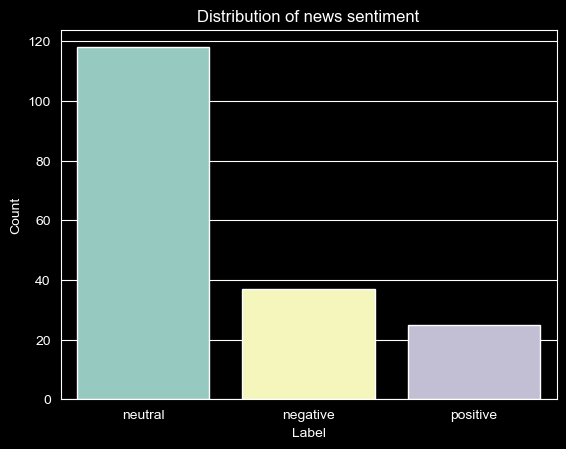

In [9]:
sns.countplot(data=news_df,x="label",hue="label")
plt.title('Distribution of news sentiment')
plt.ylabel('Count')
plt.xlabel('Label')
plt.show()

In [ ]:
news_df['published date'].head()

In [ ]:
news_df.index=pd.to_datetime(news_df['published date'])

In [ ]:
news_df.head()

In [ ]:
news_df.sort_index(inplace=True)

In [ ]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=news_df.index,y=news_df['score'],mode='markers'))
fig.show()